# 01 – Data Audit

Checking the AI4I 2020 dataset before doing any modelling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/ai4i2020.csv")
df.shape

(10000, 14)

## 1. First look at the data

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

**What I noticed:**
- 12 of the 14 columns are numbers (3 decimal, 9 integers) and 2 are strings or text: `Product ID` and `Type`.
- Every column has 10,000 non-null values, so there are no missing values.
- `UDI` and `Product ID` are just identifiers, not measurements, so they won't be used as features.
- `Machine failure` and the five failure columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are stored as numbers but are really yes/no categories (0 or 1).
- `Type` (L, M, H) is a category stored as text, so it will need encoding before modelling.

## 2. Data dictionary

| Column | Type | Units | Role | Available at prediction time? |
|---|---|---|---|---|
| UDI | identifier | – | exclude | – |
| Product ID | identifier | – | exclude | – |
| Type | categorical (L/M/H) | – | feature | yes |
| Air temperature [K] | numerical | Kelvin | feature | yes |
| Process temperature [K] | numerical | Kelvin | feature | yes |
| Rotational speed [rpm] | numerical | rpm | feature | yes |
| Torque [Nm] | numerical | Nm | feature | yes |
| Tool wear [min] | numerical | minutes | feature | yes |
| Machine failure | categorical (0/1) | – | target | no, this is the outcome |
| TWF | categorical (0/1) | – | exclude | no, only known after a failure |
| HDF | categorical (0/1) | – | exclude | no, only known after a failure |
| PWF | categorical (0/1) | – | exclude | no, only known after a failure |
| OSF | categorical (0/1) | – | exclude | no, only known after a failure |
| RNF | categorical (0/1) | – | exclude | no, only known after a failure |

**Why the failure columns are excluded:** `TWF`, `HDF`, `PWF`, `OSF` and `RNF` say which type of failure happened, so they are only known after a failure has occurred. Using them as features would leak the answer to the model (target leakage), so they are excluded. I will only use them later to analyse the errors.

## 3. Missing values and duplicates

In [6]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [10]:
print("UDI unique:", df["UDI"].is_unique)
print("Product ID unique:", df["Product ID"].is_unique)

UDI unique: True
Product ID unique: True


In [9]:
df.drop(columns=["UDI", "Product ID"]).duplicated().sum()

np.int64(0)

**What I found:**
- There are no missing values in any column, so no imputation is needed.
- There are no duplicate rows, so nothing needs to be removed.
- `UDI` and `Product ID` are both unique, and they are just identifiers, so they are excluded from the features.
- No two rows have identical measurements either. Dropping the ID columns and checking again still gives 0 duplicates, so no row is repeated under a different ID.

## 4. Target distribution

In [11]:
print(df["Machine failure"].value_counts())
print(df["Machine failure"].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


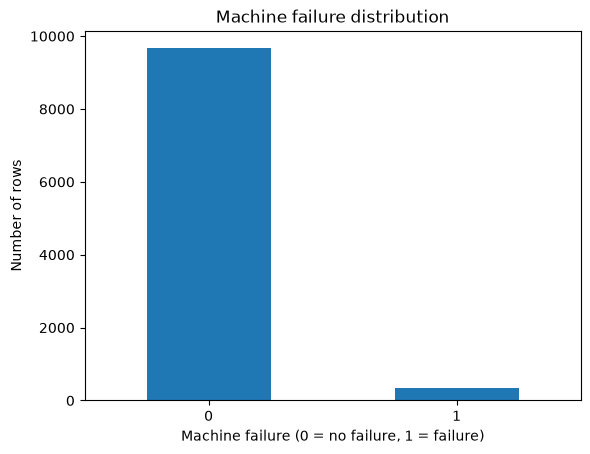

In [12]:
counts = df["Machine failure"].value_counts().sort_index()
counts.plot(kind="bar")
plt.title("Machine failure distribution")
plt.xlabel("Machine failure (0 = no failure, 1 = failure)")
plt.ylabel("Number of rows")
plt.xticks(rotation=0)
plt.show()

**What I found:**
- 339 of the 10,000 rows (3.4%) are failures and 9,661 (96.6%) are not, so the classes are heavily imbalanced.
- A model that always predicts "no failure" would be about 96.6% accurate without catching a single failure, so accuracy is misleading here.
- I will use precision, recall and F1 for the failure class instead, and a stratified train/test split so both sets keep the same 3.4% failure rate.

## 5. Failure-mode check

In [13]:
modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df[modes].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [14]:
any_mode = df[modes].sum(axis=1) > 0
failed = df["Machine failure"] == 1

print("Failures with no failure type flagged:", (failed & ~any_mode).sum())
print("Failure type flagged but no failure:", (~failed & any_mode).sum())

Failures with no failure type flagged: 9
Failure type flagged but no failure: 18


In [15]:
df[~failed & any_mode][modes].sum()

TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64

**What I found:**
- Failure types are rare. `HDF` (115), `OSF` (98) and `PWF` (95) are the most common, `TWF` has 46, and `RNF` has only 19.
- The labels are not perfectly consistent: 9 failures have no failure type flagged, and 18 rows have a failure type flagged but `Machine failure` = 0.
- All 18 of those rows are `RNF` (random failure), so 18 of the 19 random failures are not counted as a machine failure in the target.
